# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

In [2]:
# Run single simulation
I_0 = 10

infection_type = "prim" #"prim", "sec"
sim_type = "agent" #"pop_ode", "agent"

regs, dyn, ts, lin_comp, p_diff, Eff, mycNa, mycpMa,myccM, mycEin, mycEout = agent_stoch_sim(I_0 = I_0, d_I = d_I, N_0 = 10, d_IE = d_IE, 
                                                                                             d_IH = d_IH, K_IE = K_IE,
                                                                                             regulation_coeffs =  2*np.array([1.0, 1.0, -1.0, -1.0, -1.0, 1.0]),
                                                                                             infection = infection_type,
                                                                                             reg_model = "mwc_like")

S, I, A, N, E, cM, eM, H, I_d_I, I_d_IE = dyn[:,-10], dyn[:,-9], dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]

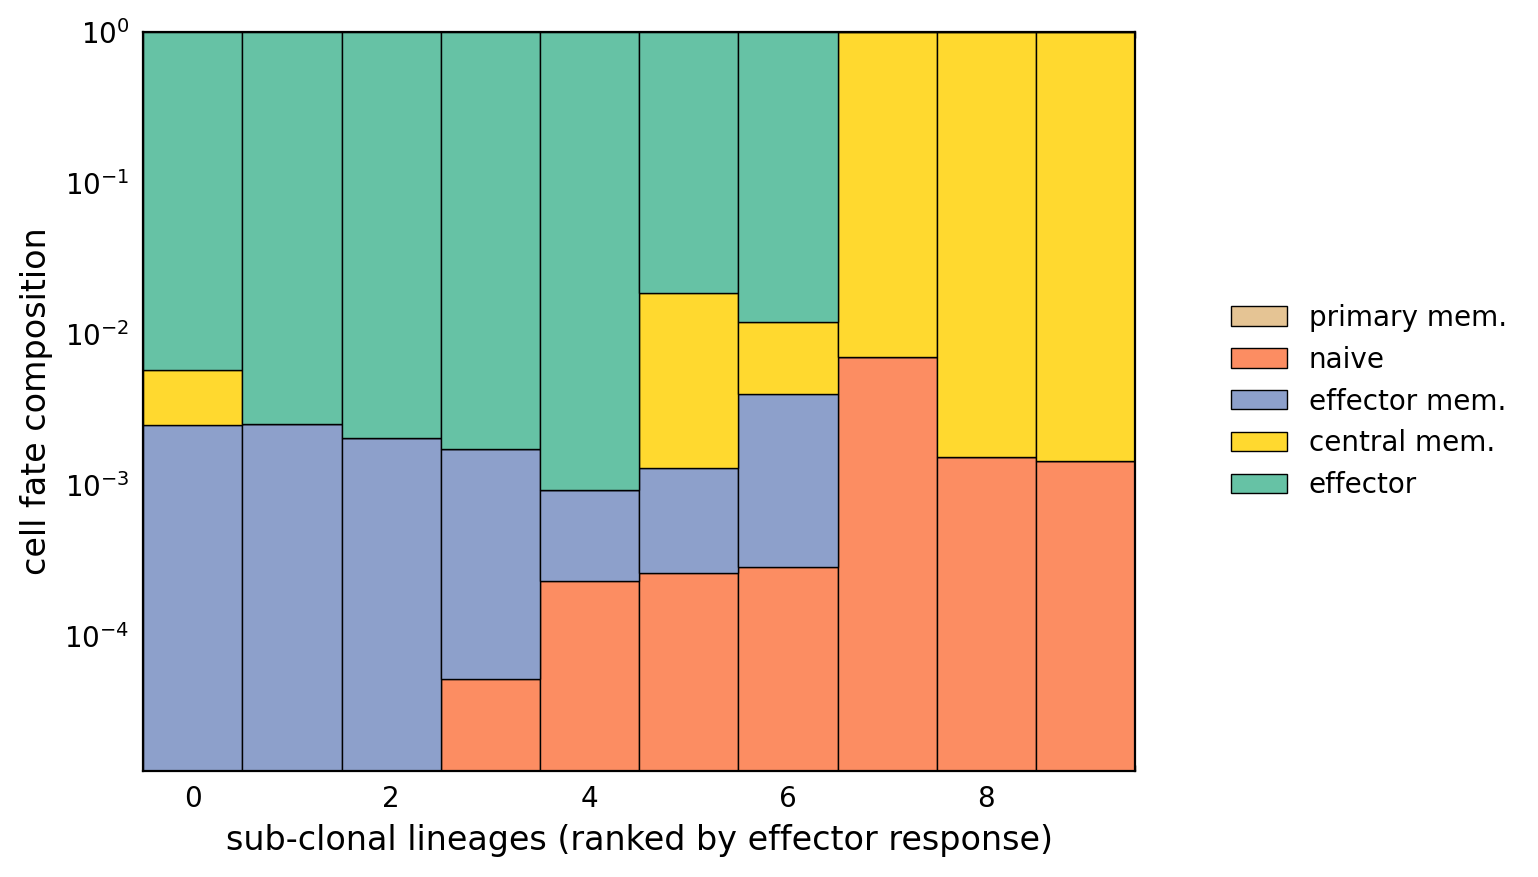

In [3]:
keys = np.array(['naive', 'primary mem.', 'central mem.', 'effector', 'effector mem.'])
all_counts = lin_comp[:-2].T
effector_ranking = np.argsort(all_counts[:, 3])[::-1]
all_counts = all_counts[effector_ranking]
total_counts = all_counts.sum(axis=1)
norm_counts = all_counts / total_counts[:, None]
norm_counts[~np.isfinite(norm_counts)] = 0
comp_argsort = np.argsort(np.max(all_counts, axis=0))
bar_dict = {k: v for k, v in zip(keys[comp_argsort], norm_counts.T[comp_argsort])}
lineage_idxs = np.arange(all_counts.shape[0])

fig, ax = plt.subplots()
bottom = np.zeros(len(lineage_idxs))
cmap_colors = sns.color_palette('Set2', 10)
cmap_colors = [cmap_colors[i]
               for i in [6, 1, 2, 5, 0]]
# cmap_colors = [cmap_colors[i]
#                for i in [5, -3, 1, 2, 0]]
width = 1

for i, (celltype, fraction) in enumerate(bar_dict.items()):
    ax.bar(lineage_idxs, fraction, width,
           edgecolor='k', linewidth=0.5,
           label=celltype, bottom=bottom, color=cmap_colors[i])
    bottom += fraction
    
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_xlim(-0.5, len(all_counts) - 0.5)
ax.set_xlabel('sub-clonal lineages (ranked by effector response)')
ax.set_ylabel('cell fate composition')
ax.set_yscale('log')

fig.savefig("_figs/"+infection_type+'-'+'cell-fates-by-lineages.png', dpi=300, bbox_inches="tight")

0.008675636575411481


[]

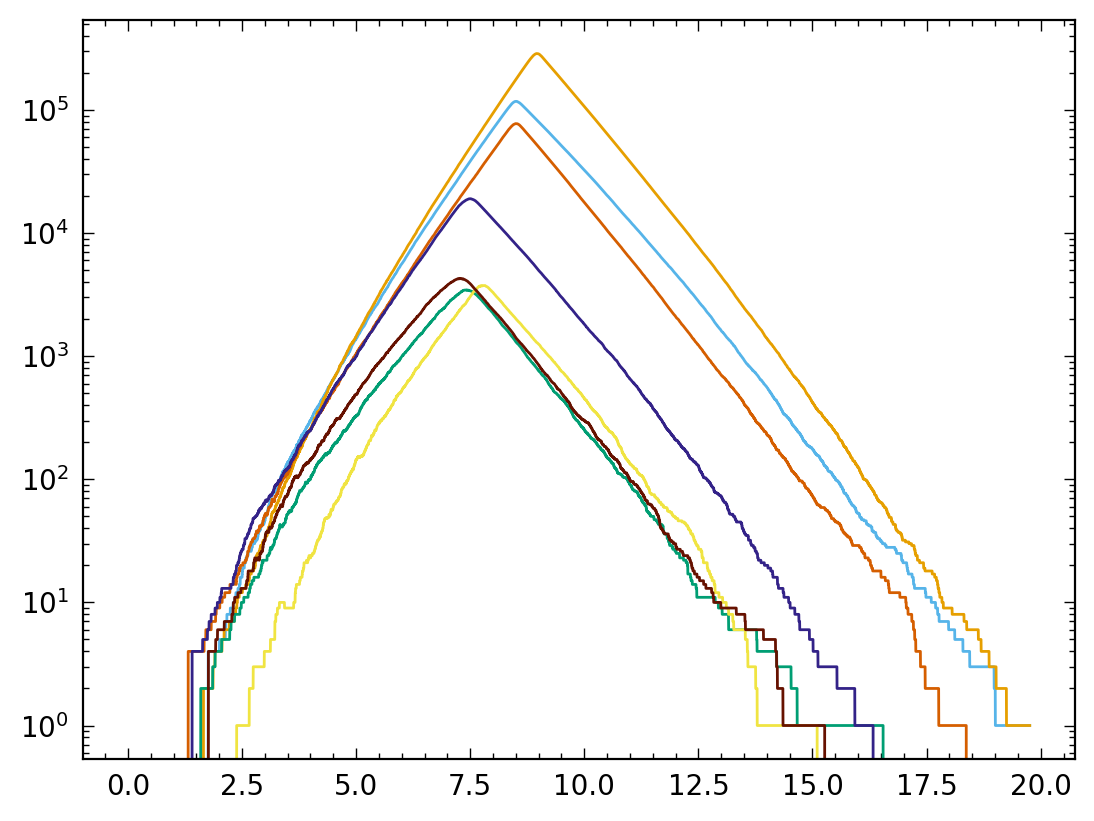

In [4]:
print(np.amax(cM + eM)/np.amax(E))
#print(E[np.argmax(E):np.argmax(E)+500])
plt.plot(ts, Eff)
plt.semilogy()

1747.1617321690164


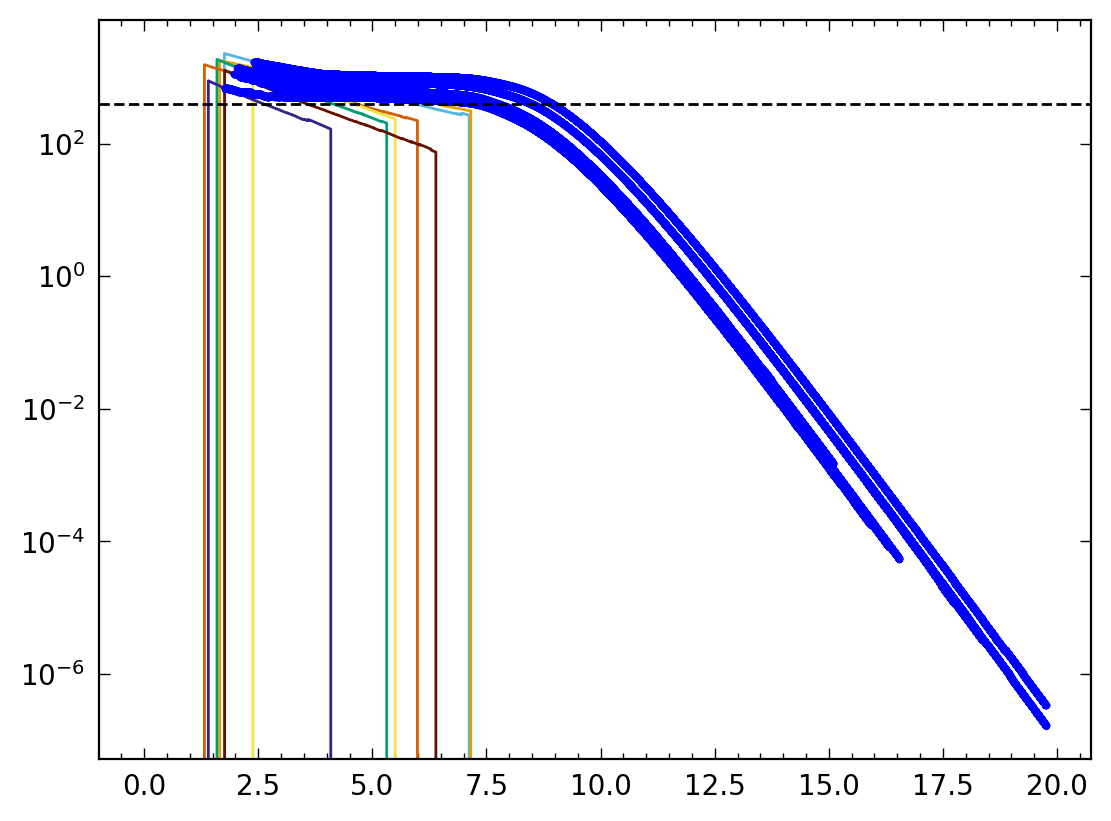

In [5]:
#plt.plot(ts, Eff)
#plt.plot(ts, mycpMa, 'k')
plt.plot(ts, mycEin) #, 'r--')
plt.plot(ts, mycEout, 'b.')
plt.axhline(y = myc_thresh, color = 'k', linestyle = '--')
#plt.plot(ts[0:1000], S[0:1000])
plt.semilogy()
print(np.amax(mycEout))

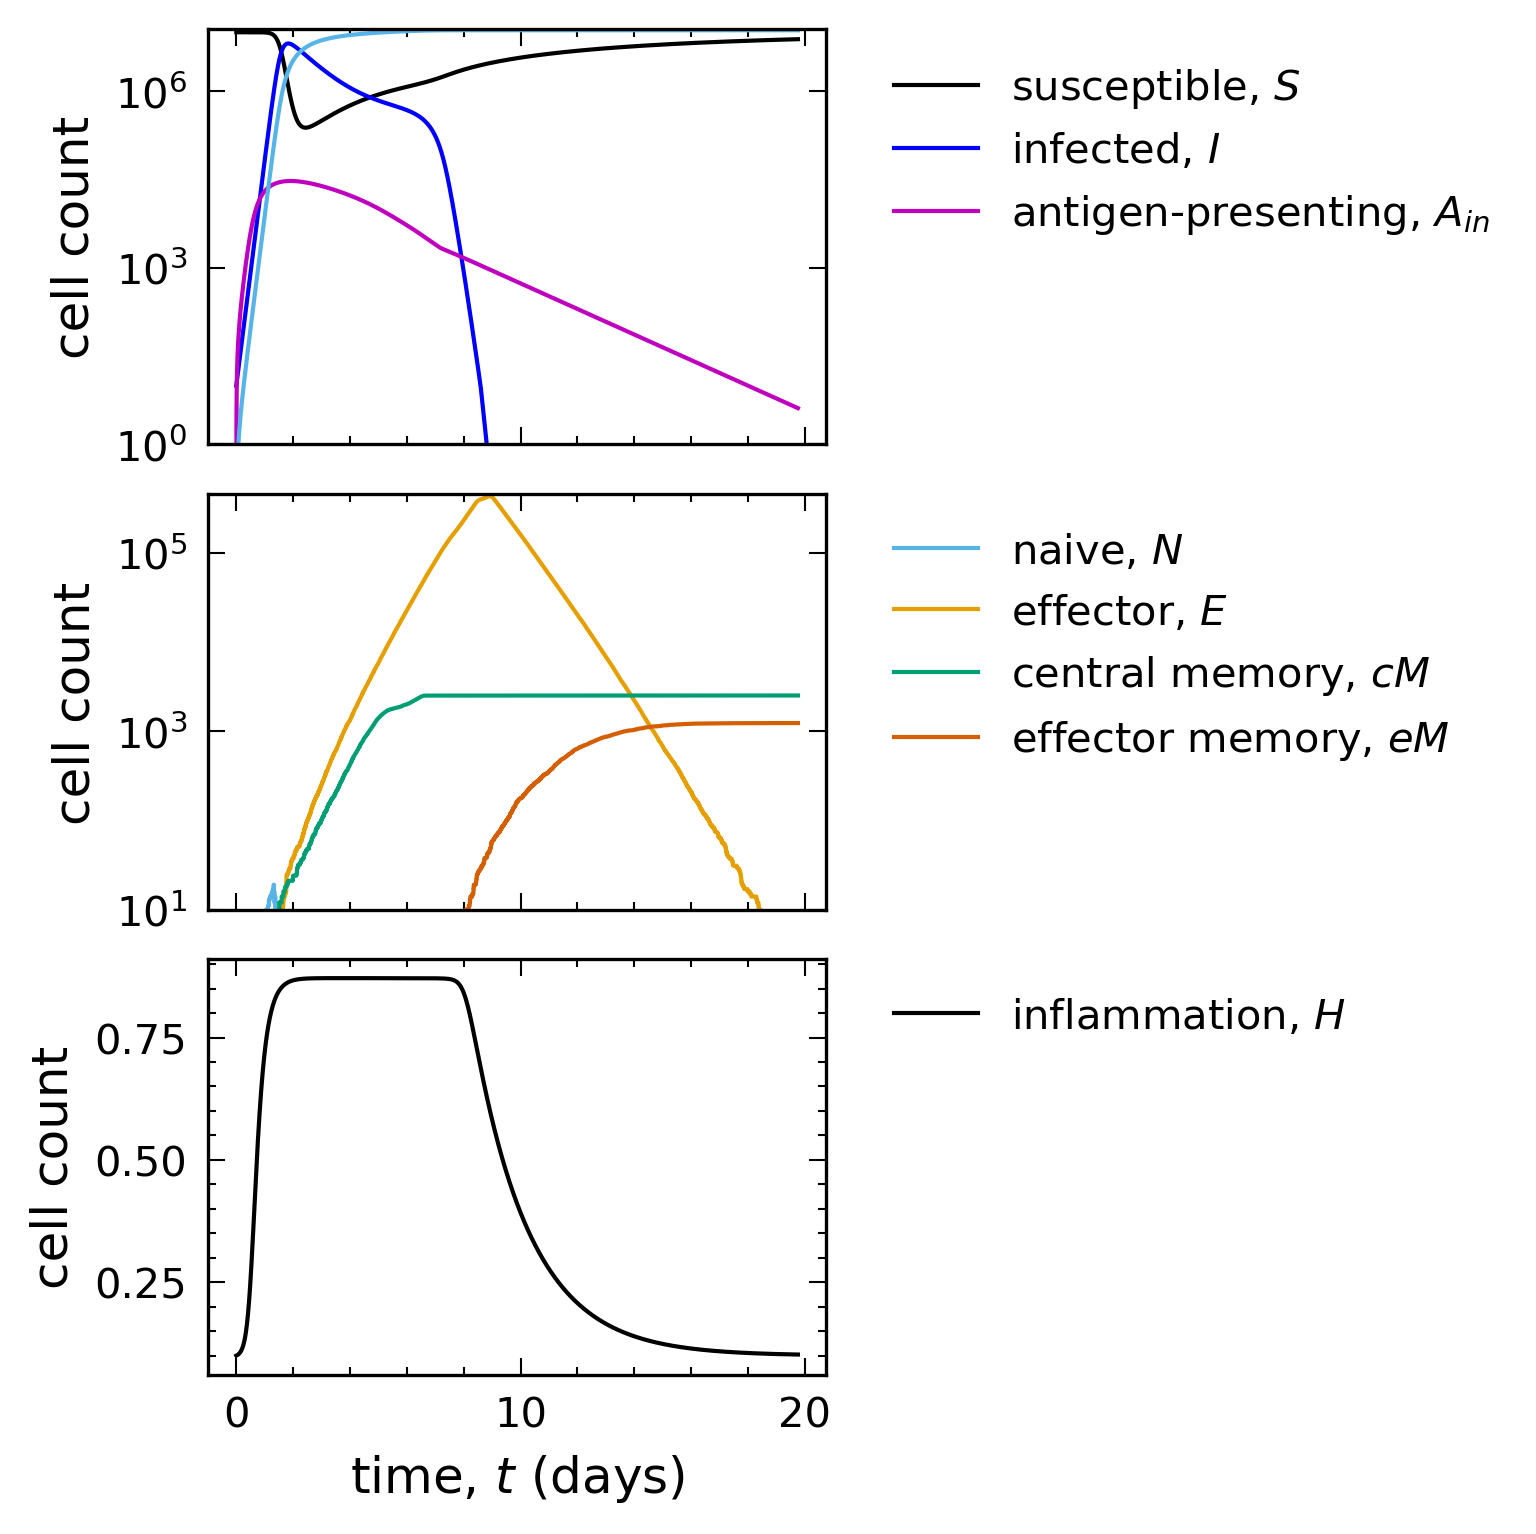

In [6]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))

ax1.plot(ts, S, 'k', label = r'susceptible, $S$')
ax1.plot(ts, I, 'b', label = r'infected, $I$')
ax1.plot(ts, A, 'm', label = r'antigen-presenting, $A_{in}$')
ax1.plot(ts, I_d_I)
ax1.set(ylabel='cell count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'naive, $N$')
ax2.plot(ts, E, label = r'effector, $E$')
ax2.plot(ts, cM, label = r'central memory, $cM$')
ax2.plot(ts, eM, label = r'effector memory, $eM$')
ax2.set(ylabel='cell count')
ax2.set_ylim(10,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(ts, H,'k-', label = r'inflammation, $H$')
ax3.set(xlabel=r'time, $t$ (days)', ylabel='cell count')
#ax3.semilogy()
#ax3.set_ylim(1,)
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig("_figs/"+infection_type+'-'+'virus-effector dynamics.png', dpi=300, bbox_inches="tight")

In [7]:
dt = sim_duration/sim_steps

np.array([np.sum(I_d_I*dt)/sim_duration, 
          np.sum(I_d_IE*dt)/sim_duration,
          np.argmax(I)*dt,
          np.max(E),
          np.argmax(E)*dt, 
          cM[-1], 
          np.sum(E*dt)/sim_duration, 
          np.log( np.sum(E*dt)/sim_duration ) if np.sum(E*dt) > 0 else 0.0,
          eM[-1]])

array([9.15263833e+06, 1.25981580e+06, 1.82800000e+00, 4.32706000e+05,
       8.93000000e+00, 2.51800000e+03, 4.98726953e+04, 1.08172289e+01,
       1.23600000e+03])

Text(0.5, 0.98, 'Peak response response: $N_0=$ 10, $d_I=$1.0')

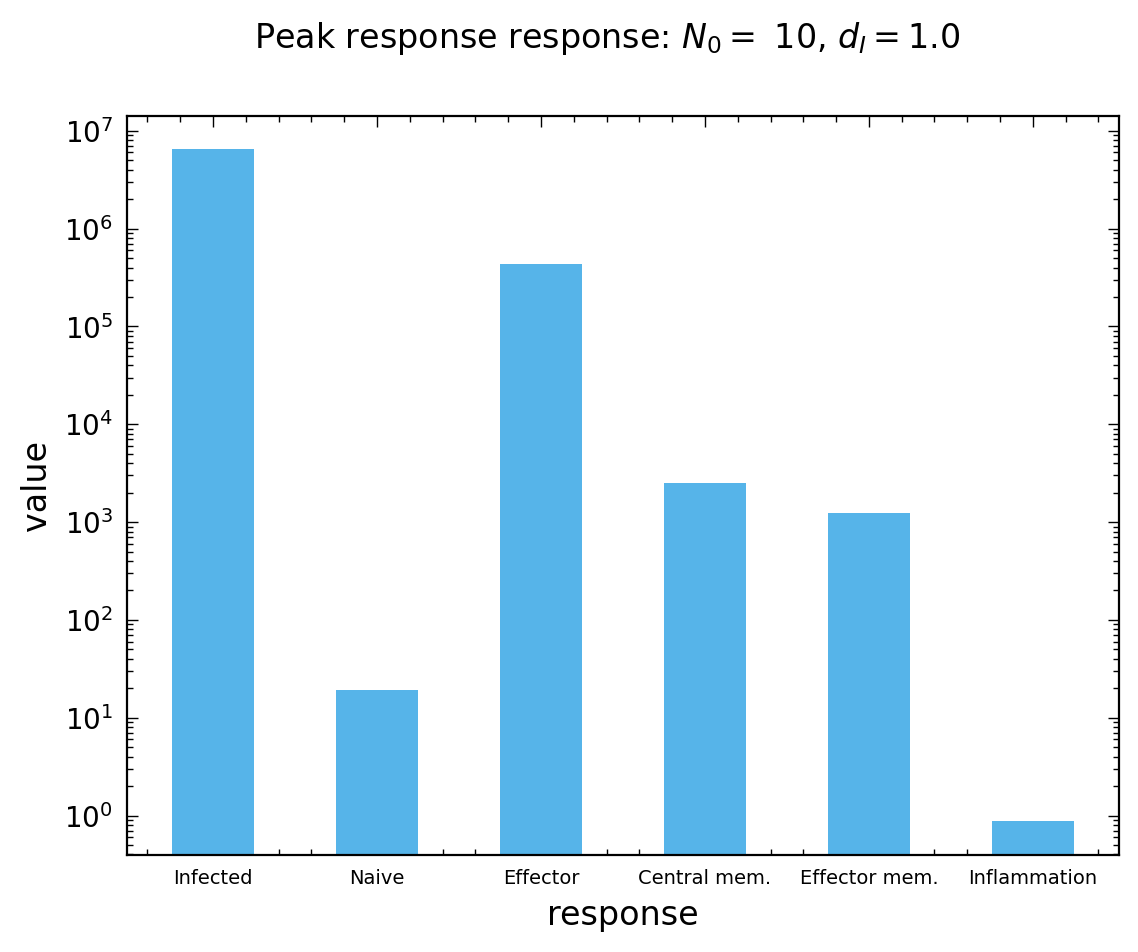

In [8]:
# Compute max values in the data
r = np.arange(6)
width = 0.5
plt.bar(r, np.amax(np.array([I, N, E, cM, eM, H]).T, axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r, ["Infected","Naive","Effector","Central mem.","Effector mem.", "Inflammation"], fontsize = 7)

plt.semilogy()
plt.suptitle(r'Peak response response: $N_0=$ '+str(N_0) +r', $d_I=$'+str(d_I))
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'peak-response'+'.png', dpi=150)

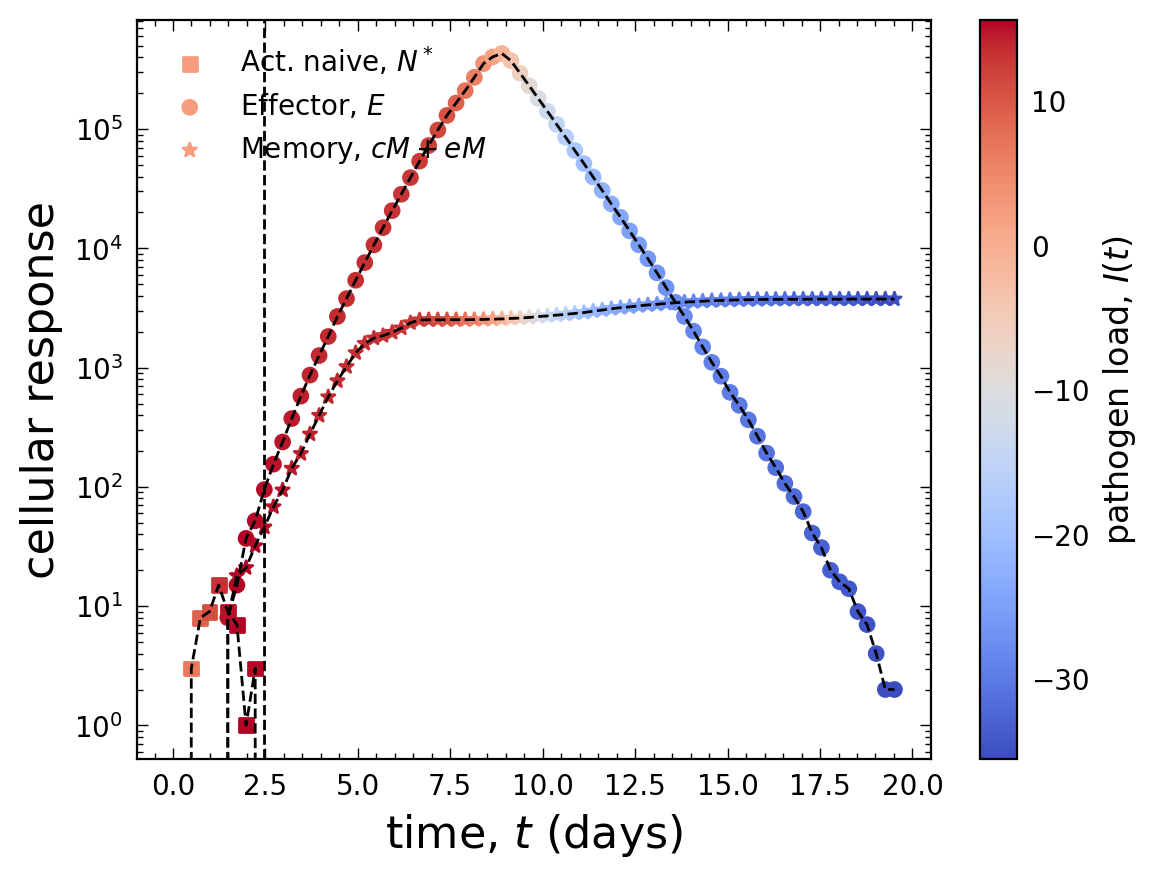

In [9]:
# Plot simulated infection dynamics: pretty plots
pnts = 80
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
naive = N[keep]
eff = E[keep]
mem = (cM+eM)[keep]
p_load = np.log(I[keep])
time = ts[keep]

plt.scatter(time, naive, marker ='s', c =p_load, cmap='coolwarm', 
            label = r'Act. naive, $N^*$')
plt.plot(time, naive, 'k--')
plt.scatter(time, eff, marker ='o', c =p_load, cmap='coolwarm', 
            label = r'Effector, $E$')
plt.plot(time, eff, 'k--')
plt.scatter(time, mem, marker ='*', c =p_load, cmap='coolwarm',
            label = r'Memory, $cM+eM$')
plt.plot(time, mem, 'k--')

plt.axvline(x = time[np.argmin(naive[5:]) + 5], color = 'k', linestyle = '--')

#plt.text('$\tau_I=$ '+str(tau_I) +r', $d_I=$'+str(d_I), fontsize=8)
plt.colorbar(label =r"pathogen load, $I(t)$")
plt.ylabel('cellular response', fontsize = 16)
plt.xlabel(r"time, $t$ (days)", fontsize = 16)
plt.semilogy()
plt.legend(loc='upper left')

#plt.savefig('_figs/timeline-of-infection-dynamics-greedy-accu.png', dpi=300, bbox_inches="tight")

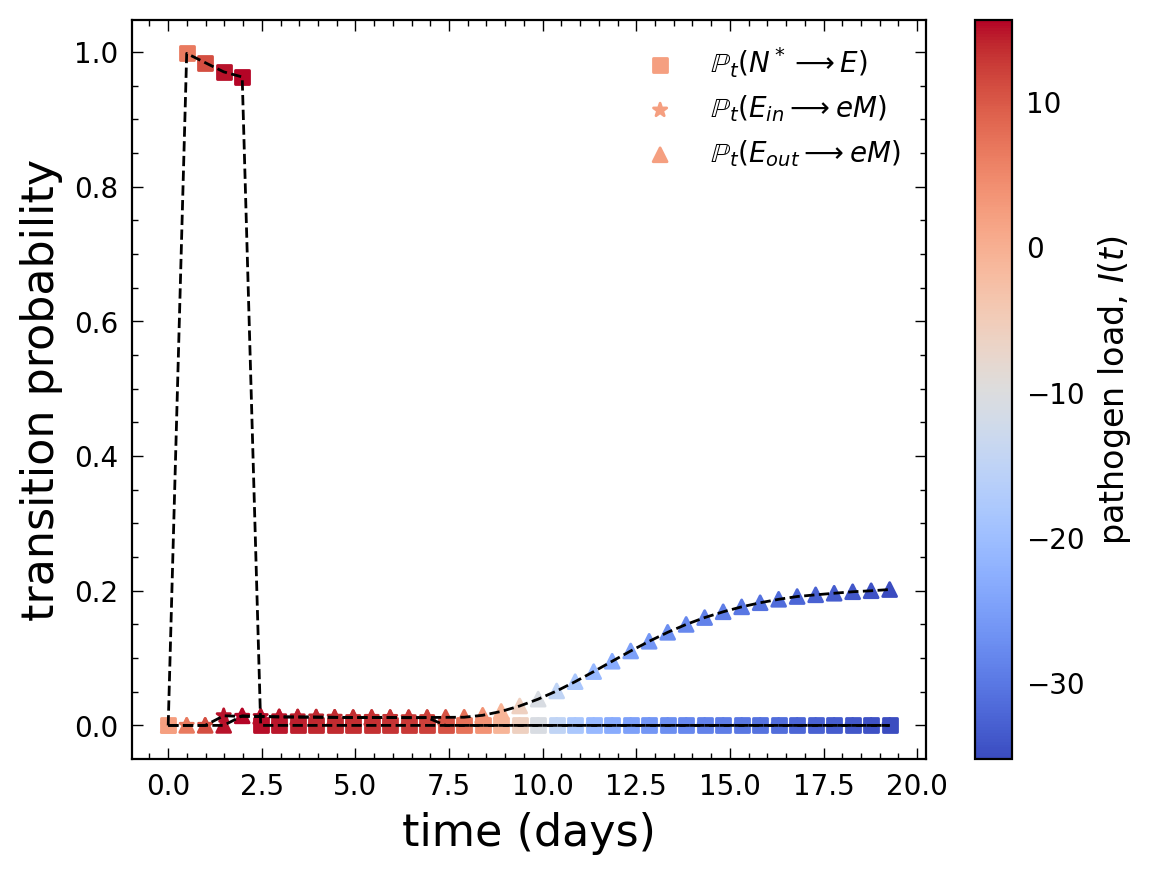

In [10]:
# Plot simulated infection dynamics: pretty plots
pnts = 40
keep = [i*int(len(E)/pnts) for i in np.arange(0,pnts)]
prob_diff = p_diff[keep]
p_load = np.log(I[keep])
time = ts[keep]

plt.scatter(time, prob_diff[:,0], marker = 's', c =p_load, cmap='coolwarm', 
            label = r'$\mathbb{P}_t(N^* \longrightarrow E)$')
plt.plot(time, prob_diff[:,0],'k--')
if infection_type == "sec":
    plt.scatter(time, prob_diff[:,3], marker = 'o', c =p_load, cmap='coolwarm', 
                label = r'$\mathbb{P}_t(pM \longrightarrow E)$')
    plt.plot(time, prob_diff[:,3],'k--')
plt.scatter(time, prob_diff[:,1], marker = '*', c =p_load, cmap='coolwarm', 
            label = r'$\mathbb{P}_t(E_{in} \longrightarrow eM)$')
plt.plot(time, prob_diff[:,1],'k--')
plt.scatter(time, prob_diff[:,2], marker = '^', c =p_load, cmap='coolwarm', 
            label = r'$\mathbb{P}_t(E_{out} \longrightarrow eM)$')
plt.plot(time, prob_diff[:,2],'k--')

plt.colorbar(label =r"pathogen load, $I(t)$")
plt.ylabel('transition probability', fontsize = 16)
plt.xlabel("time (days)", fontsize = 16)
plt.legend() #bbox_to_anchor=(1.05, 1.0), loc='upper left')

#plt.savefig('_figs/diff-prob-over-time-gr-s_harm.png', dpi=300, bbox_inches="tight")

In [ ]:
n = 7
K_IEs = K_IE*(10.0**(np.arange(0,n)-3))

#harm_min_max = np.zeros((2,n))

# for i, k in enumerate(K_IE*(10.0**(np.arange(0,n)-3))):
#     regs, dyn, ts, lin_comp, p_diff, Eff, mycNa, mycpMa,myccM, mycEin, mycEout = agent_stoch_sim(I_0 = I_0, d_I = d_I, N_0 = 10, d_IE = d_IE, 
#                                                                                              d_IH = d_IH, K_IE = K_IE,
#                                                                                              regulation_coeffs =  2*np.array([1.0, 1.0, -1.0, -1.0, -1.0, 1.0]),
#                                                                                              infection = "sec",
#                                                                                              reg_model = "mwc_like")

#     harm_min_max[0, i] = np.amax(dyn[:,-2])
    
#     regs, dyn, ts, lin_comp, p_diff, Eff, mycNa, mycpMa,myccM, mycEin, mycEout = agent_stoch_sim(I_0 = I_0, d_I = d_I, N_0 = 10, d_IE = d_IE, 
#                                                                                              d_IH = d_IH, K_IE = K_IE,
#                                                                                              regulation_coeffs =  2*np.array([-1.0, -1.0, 1.0, 1.0, -1.0, 1.0]),
#                                                                                              infection = "sec",
#                                                                                              reg_model = "mwc_like")

    
    
min_harm = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(n/15),1))(delayed(agent_stoch_sim)(N_0 = 10, 
                                                                                                  K_IE = k,
                                                                                                  regulation_coeffs =  2*np.array([1.0, 1.0, -1.0, -1.0, -1.0, 1.0]),
                                                                                                  infection = "sec")
                                              for k in K_IEs), dtype=object)
    
max_harm = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(n/15),1))(delayed(agent_stoch_sim)(N_0 = 10, 
                                                                                                  K_IE = k,
                                                                                                  regulation_coeffs =  2*np.array([-1.0, -1.0, 1.0, 1.0, -1.0, 1.0]),
                                                                                                  infection = "sec")
                                              for k in K_IEs), dtype=object)
    

These lineages did not respond to a primary infection: [1 1 1 1 0 1 1 1 1 1]
These lineages produced memory during the primary infection: [0 0 0 0 1 0 0 0 0 0]
These lineages did not respond to a primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages produced memory during the primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages did not respond to a primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages produced memory during the primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages did not respond to a primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages produced memory during the primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages did not respond to a primary infection: [0 0 0 0 0 0 0 0 0 0]
These lineages produced memory during the primary infection: [0 0 0 0 0 0 0 0 0 0]


array([[10742343.57963894, 10822280.86206273, 10842665.91705363,
        10550911.46908835, 11480034.6584786 , 18489325.18796099,
        10611416.47816962],
       [20706864.74911803, 20706864.74911803, 20706864.74911803,
        20706864.74911803, 20706864.74911803, 20706864.74911803,
        20706864.74911803]])

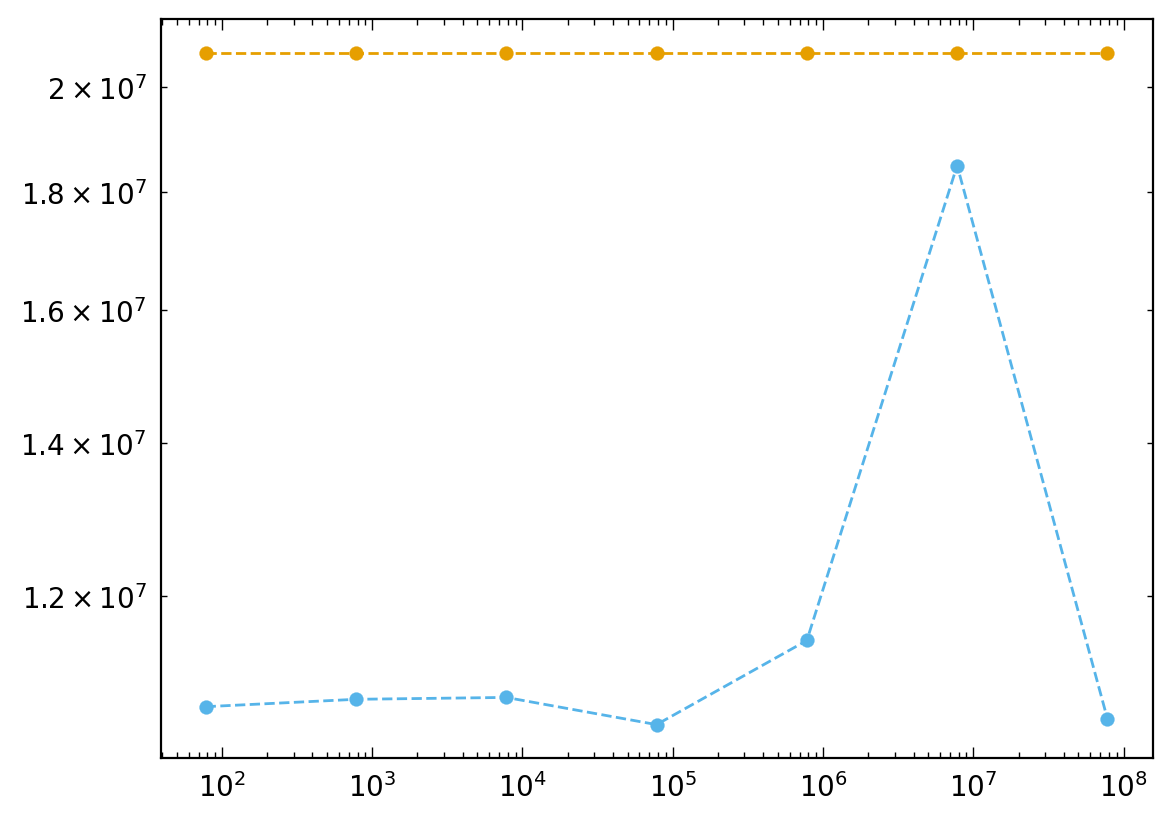

In [30]:
plt.plot(K_IE*(10.0**(np.arange(0,n)-3)), harm_min_max.T, 'o--')
plt.semilogx()
plt.semilogy()

harm_min_max

In [11]:
# # Plot ranking MI of networks
# from matplotlib.offsetbox import AnchoredText
# fig, axs = plt.subplots(3,2, dpi = 300, constrained_layout = True, figsize = (6,8))

# d_Is = d_I*np.array([0.01, 0.1, 1.0, 5.0, 5.0])
# N0s = N_0*np.array([1.0, 1.0, 1.0, 1.0, 10.0])

# for i, ax in enumerate(axs.flat):
    
#     regs, dyn, ts, Eff, p_diff,_,_,_,_ = agent_stoch_sim(I_0 = I_0, d_I = d_Is[i], N_0 = int(N0s[i]), d_IE = d_IE, d_IH = d_IH,
#                     infection = infection_type)
#     S, I, A, N, E, cM, eM, H = dyn[:,-8], dyn[:,-7], dyn[:,-6], dyn[:,-5], dyn[:,-4], dyn[:,-3], dyn[:,-2], dyn[:,-1]
    
#     #response = np.sum( np.log( np.maximum(np.array([I, N, E, cM, eM, eTr]), 1) ), axis = 1)*(ts[1]-ts[0])
#     response = np.amax(np.array([I, N, E, cM, eM, H]), axis =1)
    
#     anchored_text = AnchoredText(r'$N_0=$ '+str(N0s[i]) +r', $d_I=$'+str(d_Is[i]), 
#                                  prop=dict(size=8), loc = "upper right")
    
#     r = np.arange(6)
#     width = 0.5
#     ax.bar(r, response, width = width, label = r'vary $N_0$')
#     ax.semilogy()
#     #ax.set(ylabel = r"$\int_0^{T_{sim}}\log(\cdot)dt$", xlabel = 'cell type')
#     ax.set(ylabel = r"$\max(\cdot)$", xlabel = 'cell type')
#     ax.set_xticks(r)
#     ax.set_xticklabels([r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$", r"$H$"])
#     ax.add_artist(anchored_text)
    
# #fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'responses-in-pathogen-regimes.png', dpi=300)

In [12]:
# fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=150)

# # This sets how many simulations are performed.
# num_realizations = 50
# plot_labels = [r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

# trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
# for idx in range(num_realizations):
#     _, I, N, E, cM, eM, T, ts = stoch_sim(infection = infection_type)

#     trajectories[idx] = I, N, E, cM, eM
# print(trajectories.shape)
# # Filter out the entries in the numpy array which were full of zeros
# # so they aren't plotted.
# where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
# trajectories = trajectories[where_nonzero]

# # Compute the mean and standard deviation over all the rows at each column.
# # Plot the mean as a solid line and the mean +/- std as fill.
# for states, ax in enumerate(axes):
#     means = np.mean(trajectories[:,states,:], axis=0)
#     stds = np.std(trajectories[:,states,:], axis=0)
#     ax.plot(ts, means, 'k-')
#     #ax.semilogy()
#     ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# # Make legend appear.
# # for ax in axes:
# #     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# # Set xlabel.
# for states, ax in enumerate(axes):
#     if states == 4:
#         ax.set_xlabel('time, $t$', fontsize=13)
    
# # Set ylabels.
# ylabels = plot_labels
# for ax, ylabel in zip(axes, ylabels):
#     ax.set_ylabel(ylabel, fontsize=13)

# # Align y-axis labels.
# fig.align_ylabels(axes)

# fig.tight_layout()
# plt.show()
# fig.savefig("_figs/"+infection_type+'-'+'population-virus-effector dynamics.png', dpi=150, bbox_inches="tight")

## (2) Parallelize simulation runs

In [13]:
# Parallelize simulation runs
def for_parallel(params,
                 sim_kind = sim_type):
    
    return sum_sim(d_I = params[0], N_0 = params[1],
                   regulation_coeffs = [1.0, 1.0, -1.0, -1.0, 1.0, 1.0],
                   infection = infection_type, 
                   sim_kind = sim_kind)

In [14]:
# Set global simulation parameters
runs = 2

dI_N0s = sample_2d(runs = runs)

In [15]:
# run several simulations varying d_I, N_0 indep
run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=max(int(len(dI_N0s)/40),1))(delayed(for_parallel)(params = params)
                                              for params in dI_N0s), dtype=object)

## (3) Plot distribution of response statistics from simulations varying $b_{I}$ and $\tau_I$

In [16]:
run_data_INs = np.stack(run_data).astype(None)
print(run_data_INs)

[[ 1.00000000e+00  1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+01  1.00000000e-01
   1.34832998e+00  1.20000000e+01  7.80000000e+04  4.77676617e+06
   4.77676617e+06  1.84200000e+00  1.84200000e+00  4.77639855e+05
   4.77639855e+05  4.14270543e+05  4.14270543e+05  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  2.10000000e+01
   2.10000000e+01  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  8.09827275e-01  8.09827275e-01]
 [ 1.00000000e+00  1.00000000e+00 -1.00000000e+00 -1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+01  2.55000000e+00
   1.35455766e+00  1.20000000e+01  7.80000000e+04  3.44568679e+05
   3.44568679e+05  2.06160000e+00  2.06160000e+00  8.78607615e+05
   8.78607615e+05  4.34848580e+04  4.34848580e+04  3.97190000e+04
   3.97190000e+04  9.11760000e+00  9.11760000e+00  0.00000000e+00
   0.00000000e+00  7.57429340e+03  7.57429340e+03  3.76300000e+03
   3.76300000e+03  8.2331

In [17]:
# run_rates = np.zeros((runs, len(run_data[:,0][0]) ))
# run_data_Is = np.zeros((runs, len(run_data[:,1][0]) ))

# for i in np.arange(0,runs):
#     run_rates[i,:] = run_data[:,0][i]
#     run_data_Is[i,:] = run_data[:,1][i]

Text(0.5, 0.98, 'Max response')

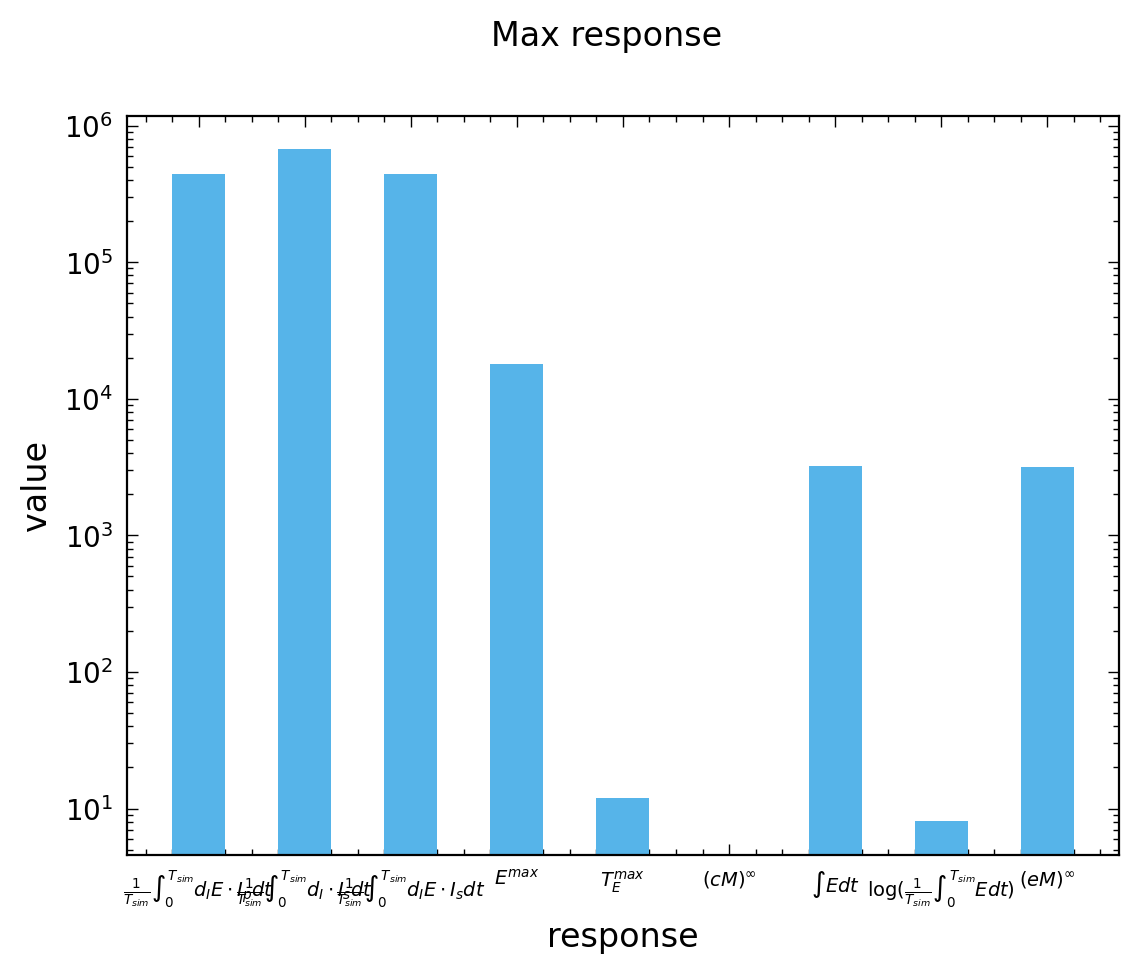

In [18]:
# Compute max values in the data
r = 2*np.arange(9)
width = 1
plt.bar(r, np.amax(run_data_INs[:,-9:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r,stat_names[-9:], fontsize = 7)

plt.semilogy()
plt.suptitle('Max response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-max'+'.png', dpi=150)

In [19]:
# # # Troubleshooting outliers
# print(run_data_Is[np.argmin(run_data_Is[:, 11]),:])
# print(run_data_Is[np.argmax(run_data_Is[:, 15]),:])
# immune_param= run_rates[np.argmax(run_data_Is[:, 15]), :]
# virus_param = (run_data_Is[np.argmax(run_data_Is[:, 15]), :])[6:10]

# rates, I, N, E, cM, eM, T, ts = stoch_sim(virus_param[0], virus_param[1], virus_param[2], virus_param[3],
#                                           rates = immune_param,
#                                           noise_model = "pop", 
#                                           rate_cv = [0.0, 0.0, 0.0, 0.0],
#                                           infection = infection_type)

# plt.plot(ts,np.array([I, E, cM]).T)
# plt.semilogy()
# # plt.plot(ts,np.array([p_A(tau_I,I)]).T)

# print(immune_param)

Text(0.5, 0.98, 'Min response')

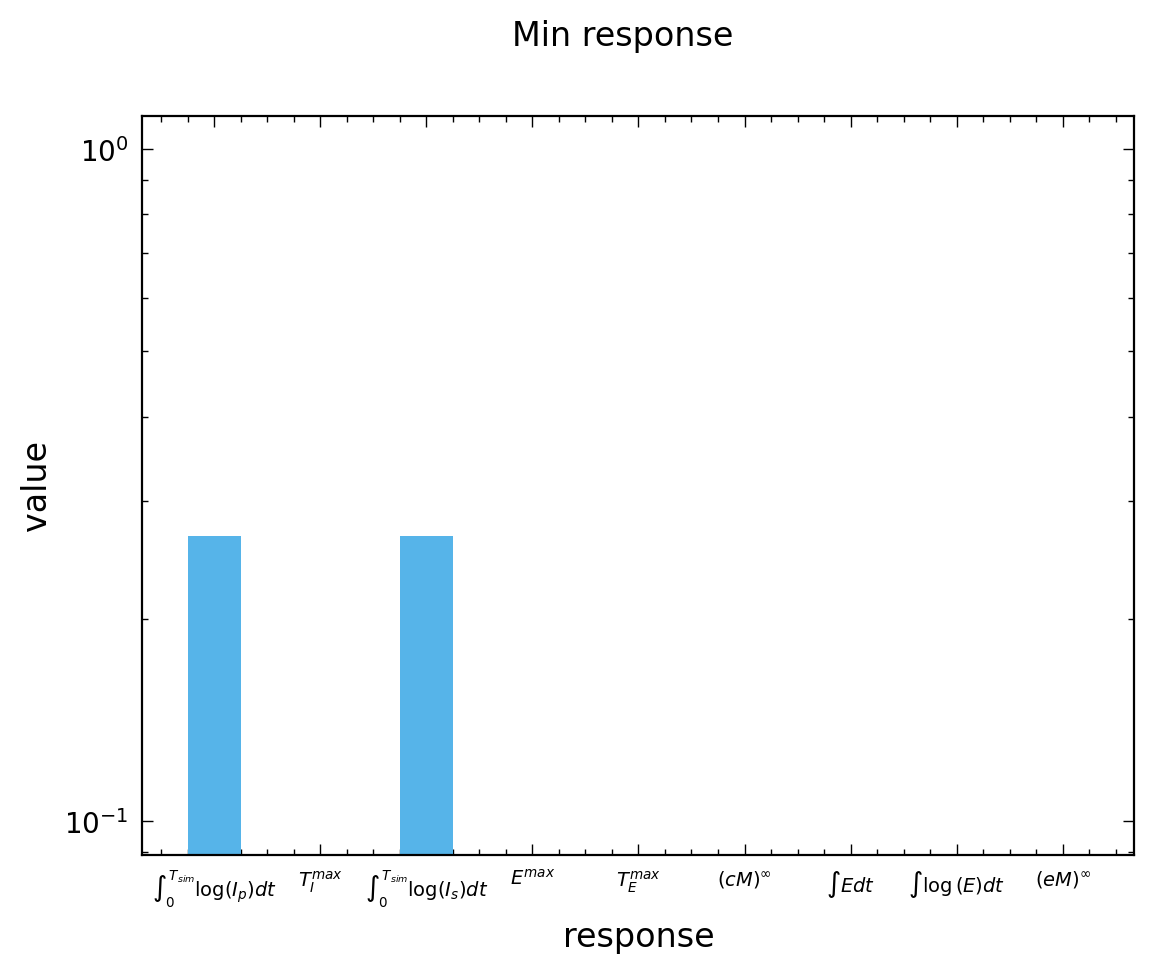

In [20]:
# Compute minimum values in the data
r = 2*np.arange(9)
width = 1
plt.bar(r, np.amin(run_data_INs[:,-9:], axis = 0), width = width)

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r,stat_names[-9:], fontsize = 7)

plt.semilogy()
plt.suptitle('Min response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-min'+'.png', dpi=150)

## (4) Compute mutual information between variables

In [24]:
# compute mutual information
MI_d_I = np.zeros(run_data_INs.shape[1])
for i in np.hstack(([7],np.arange(10,len(stat_names)))):
    MI_d_I[i] = calc_MI(run_data_INs[:,7], run_data_INs[:,i])

MI_N_0 = np.zeros(run_data_INs.shape[1])
for i in np.hstack(([8],np.arange(10,len(stat_names)))):
    MI_N_0[i] = calc_MI(run_data_INs[:,8], run_data_INs[:,i])

Text(0.5, 0.98, 'Entropy in generated data')

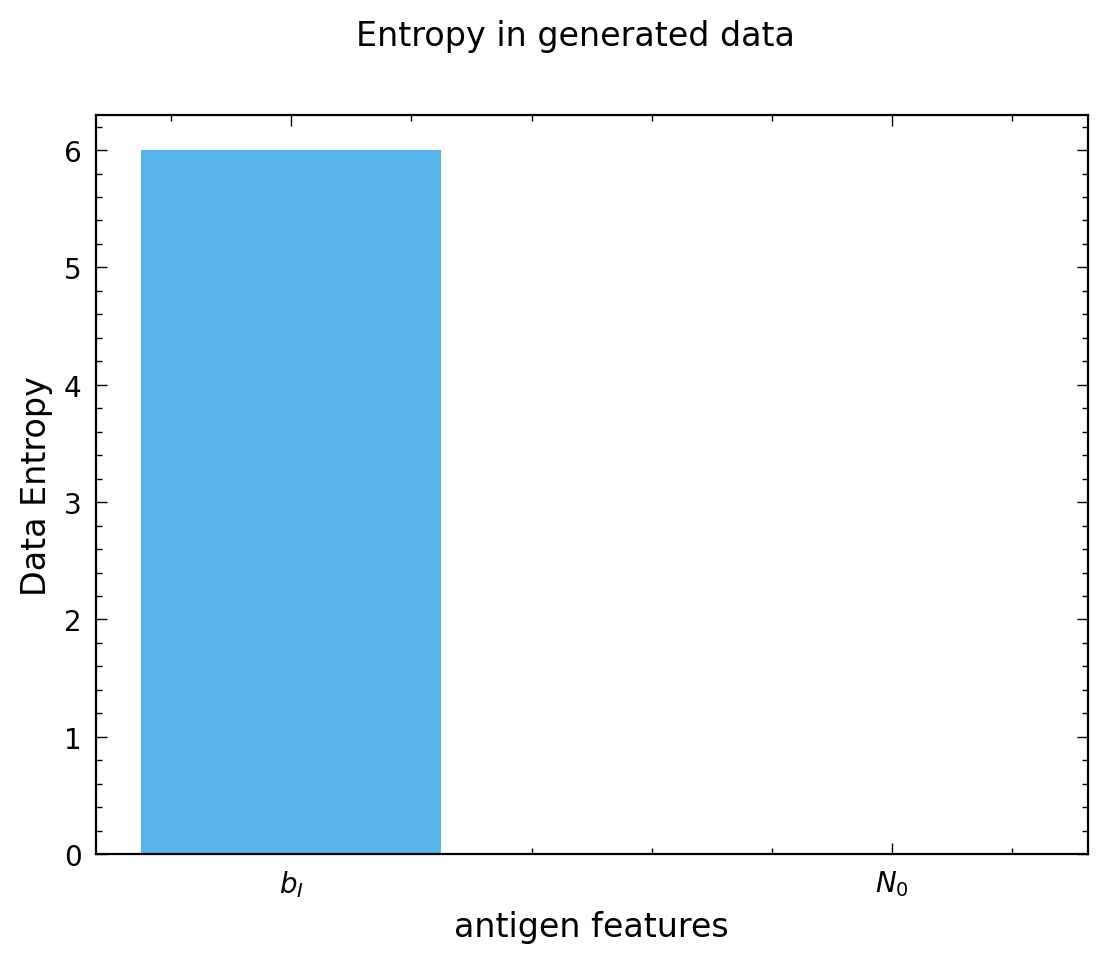

In [25]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(2)
width = 0.5
plt.bar(r, np.array([MI_d_I[7],MI_N_0[8]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[7:9])
plt.suptitle(r'Entropy in generated data')
#plt.savefig("_figs/"+infection_type+'-'+'response-mutual-info-gauss-tau_I-'+str(tau_I)+'.png', dpi=150, bbox_inches="tight")

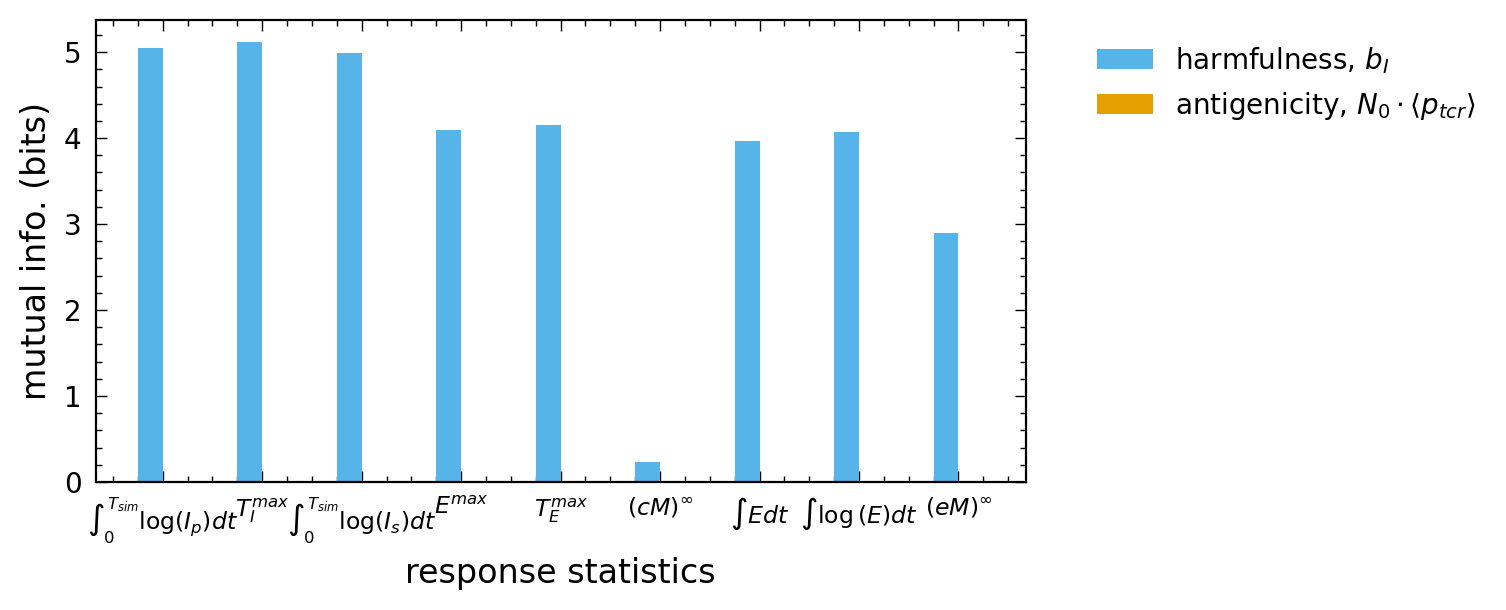

In [26]:
# Plot mutual information
plt.figure(figsize=(6,3))

r = 2*np.arange(len(MI_d_I[10:]))
width = 0.5
plt.bar(r, MI_d_I[10:], width = width, label = r'harmfulness, $b_{I}$')
plt.bar(r + width, MI_N_0[10:], width = width, label = r'antigenicity, $N_0\cdot\langle p_{tcr}\rangle$')


plt.xlabel("response statistics", fontsize = 12)
plt.ylabel("mutual info. (bits)", fontsize = 12)

plt.xticks(r + width/2,stat_names[-9:],fontsize=8.5)
plt.legend(loc='upper right')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.suptitle(r'MI (bits) between $b_{I}, \tau_I,$ and response')
#plt.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-mutual-info-gr-harm.png', dpi=300, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [ ]:
# Plot trajectories for d_I

# fig_d_I.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_d_I.savefig('plot-response-varying-d_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[-9:]
xlabels = [stat_names[7]]*len(ylabels)

fig_d_I = joint_plot_grid([run_data_INs[:,7]]* len(ylabels), run_data_INs[:,10:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

#fig_d_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-d_I.png', dpi=150,bbox_inches="tight")


In [ ]:
# Plot trajectories for tau_I
# fig_tau_I.suptitle(r'Immune response while varying $\tau_I$ (Gaussian), $\tau_I=$ '+str(tau_I))
# plt.show()
# fig_tau_I.savefig('plot-response-varying-tau_I-gauss-tau_I-'+str(tau_I)+'.png', dpi=150)
ylabels=stat_names[-9:]
xlabels = [stat_names[8]]*len(ylabels)

fig_tau_I = joint_plot_grid([run_data_INs[:,8]]*len(ylabels), run_data_INs[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_tau_I.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'plot-response-varying-tau_I.png', dpi=150)

In [ ]:
# plot surface plots
fig = plt.figure(figsize=(12,12),dpi = 150)

i = 1
num_points = np.minimum(run_data_INs.shape[0], 10000)

for val in stat_names[i+9:]:

    ax = fig.add_subplot(5, 2, i) #, projection='3d')
    # set the limits of the plot to the limits of the data
    img = ax.scatter(run_data_INs[:num_points, 7], run_data_INs[:num_points,8], c = run_data_INs[:num_points,i+9], cmap="coolwarm")
    ax.set(xlabel=r'harmfulness, $d_I$', ylabel=r'antigenicity, $\tau_I$')
    fig.colorbar(img,  shrink=0.5, aspect=8, label =val)

    i += 1
    
fig.suptitle(r'Response variables dependence on $d_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'response-distribution-gr-harm.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [ ]:
fig = plt.figure(figsize=(6,3))

# set the limits of the plot to the limits of the data
plt.scatter(run_data_INs[:10000,7], run_data_INs[:10000,8], c = run_data_INs[:10000, 10], cmap="coolwarm")
plt.xlabel(r'harmfulness, $d_I$', fontsize = 16)
plt.ylabel(r'antigenicity, $\tau_I$', fontsize = 16)
plt.semilogx()
plt.colorbar(shrink=0.5, aspect=10, label ="pathogen load\n "+stat_names[10])
    
#fig.suptitle(r'Response variables dependence on $d_I$ and $\tau_I$'+' for '+infection_type+". infection")
fig.savefig("_figs/"+sim_type+'-'+infection_type+'-'+'effectiveness-distribution-gr-harm.png', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()